In [47]:
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt


In [49]:
file_path = '../data/complaints.csv'

In [50]:
chunksize = 100_000
selected_data = []

# Step 1: Read a sample to detect column names dynamically
sample_df = pd.read_csv(file_path, nrows=5)
print("📋 Columns found:", list(sample_df.columns))

product_col = None
complaint_col = None

for col in sample_df.columns:
    col_lower = col.lower().strip()
    if 'product' == col_lower:
        product_col = col
    elif 'consumer complaint narrative' in col_lower:
        complaint_col = col

if product_col is None or complaint_col is None:
    raise ValueError("❌ Could not find expected columns ('product' and 'consumer complaint narrative').")

print(f"✅ Using columns: Product = '{product_col}', Complaint = '{complaint_col}'")

# Step 2: Read large file in chunks
for chunk in pd.read_csv(file_path, usecols=[product_col, complaint_col],
                         chunksize=chunksize, low_memory=False):
    chunk = chunk.dropna(subset=[complaint_col])
    selected_data.append(chunk)

# Step 3: Combine all chunks
df = pd.concat(selected_data, ignore_index=True)
df = df.rename(columns={product_col: 'product', complaint_col: 'consumer_complaint_narrative'})

print(f"✅ Data loaded successfully. Rows: {len(df)}, Columns: {df.columns.tolist()}")
df.head()


📋 Columns found: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
✅ Using columns: Product = 'Product', Complaint = 'Consumer complaint narrative'
✅ Data loaded successfully. Rows: 3410356, Columns: ['product', 'consumer_complaint_narrative']


,product,consumer_complaint_narrative
0,"Credit reporting, credit repair services, or o...",These are not my accounts.
1,Credit reporting or other personal consumer re...,Kindly address this issue on my credit report....
2,Credit reporting or other personal consumer re...,There are XXXX collections being reported to t...
3,Credit reporting or other personal consumer re...,"Violation of Gramm-Leach-Bliley Act ( GLBA ), ..."
4,Credit reporting or other personal consumer re...,"Good day, filing this complaint to follow up m..."


In [51]:
# Find all variants of "Credit reporting"
credit_variants = df[df['product'].str.contains('credit reporting', case=False, na=False)]['product'].unique().tolist()
print("Detected credit-reporting variants:", credit_variants)

# Select the 4 main categories
selected_products = credit_variants + ['Debt collection', 'Consumer Loan', 'Mortgage']
df = df[df['product'].isin(selected_products)]

# Map labels
label_map = {}
for v in credit_variants:
    label_map[v] = 0
label_map.update({
    'Debt collection': 1,
    'Consumer Loan': 2,
    'Mortgage': 3
})
df['label'] = df['product'].map(label_map)

print("✅ Categories filtered and labeled successfully.")
print(df['product'].value_counts())
df.head()


Detected credit-reporting variants: ['Credit reporting, credit repair services, or other personal consumer reports', 'Credit reporting or other personal consumer reports', 'Credit reporting']
✅ Categories filtered and labeled successfully.
product
Credit reporting or other personal consumer reports                             1435692
Credit reporting, credit repair services, or other personal consumer reports     807276
Debt collection                                                                  371255
Mortgage                                                                         134803
Credit reporting                                                                  31587
Consumer Loan                                                                      9461
Name: count, dtype: int64


,product,consumer_complaint_narrative,label
0,"Credit reporting, credit repair services, or o...",These are not my accounts.,0
1,Credit reporting or other personal consumer re...,Kindly address this issue on my credit report....,0
2,Credit reporting or other personal consumer re...,There are XXXX collections being reported to t...,0
3,Credit reporting or other personal consumer re...,"Violation of Gramm-Leach-Bliley Act ( GLBA ), ...",0
4,Credit reporting or other personal consumer re...,"Good day, filing this complaint to follow up m...",0


In [52]:
# Drop missing or very short complaints
df.dropna(subset=['consumer_complaint_narrative'], inplace=True)
df = df[df['consumer_complaint_narrative'].str.len() > 20]
df.rename(columns={'consumer_complaint_narrative': 'complaint_text'}, inplace=True)

print("Before balancing:")
print(df['label'].value_counts())

# Split majority and minority classes
df_majority = df[df['label'] == 0]
df_minority = df[df['label'] != 0]

# Downsample majority class to 5,000
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=5000,
    random_state=42
)

# Combine and shuffle
df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.groupby('label', group_keys=False).apply(lambda x: x.sample(5000, random_state=42))
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ After balancing:")
print(df_balanced['label'].value_counts())
print("Total rows:", len(df_balanced))


Before balancing:
label
0    2273892
1     371024
3     134791
2       9460
Name: count, dtype: int64

✅ After balancing:
label
2    5000
0    5000
1    5000
3    5000
Name: count, dtype: int64
Total rows: 20000


C:\Users\chinm\AppData\Local\Temp\ipykernel_17092\466512076.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_balanced.groupby('label', group_keys=False).apply(lambda x: x.sample(5000, random_state=42))


In [53]:
output_path = '../data/consumer_complaints_sample_balanced.csv'
df_balanced.to_csv(output_path, index=False)

print(f"✅ Saved balanced dataset → {output_path}")
print(df_balanced.shape)


✅ Saved balanced dataset → ../data/consumer_complaints_sample_balanced.csv
(20000, 3)


Label distribution:
label
2    5000
0    5000
1    5000
3    5000
Name: count, dtype: int64


C:\Users\chinm\AppData\Local\Temp\ipykernel_17092\2266026501.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\chinm\OneDrive\Desktop\Desktop\project\Kaiburr\Chinmay\kaiburr-text-classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


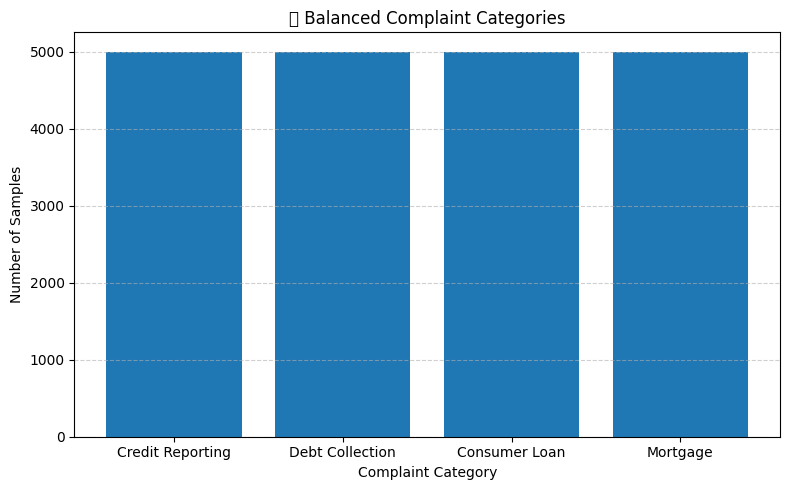

In [54]:
# Numerical check
print("Label distribution:")
print(df_balanced['label'].value_counts())

# Label name mapping
label_names = {
    0: 'Credit Reporting',
    1: 'Debt Collection',
    2: 'Consumer Loan',
    3: 'Mortgage'
}

# Plot distribution
label_counts = df_balanced['label'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index.map(label_names), label_counts.values)
plt.title("📊 Balanced Complaint Categories")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
